In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
base_path = '/Users/s.faizahmad/Desktop/ecommerce-sales-analysis/data/'

orders = pd.read_csv(base_path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(base_path + 'olist_order_items_dataset.csv')
order_payments = pd.read_csv(base_path + 'olist_order_payments_dataset.csv')
customers = pd.read_csv(base_path + 'olist_customers_dataset.csv')
products = pd.read_csv(base_path + 'olist_products_dataset.csv')
sellers = pd.read_csv(base_path + 'olist_sellers_dataset.csv')
category_translation = pd.read_csv(base_path + 'product_category_name_translation.csv')

print("✅ All datasets loaded!")
print(f"Orders: {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Payments: {order_payments.shape}")
print(f"Customers: {customers.shape}")
print(f"Products: {products.shape}")

✅ All datasets loaded!
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Customers: (99441, 5)
Products: (32951, 9)


In [5]:
# ============================================
# DATA CLEANING
# ============================================

# Date columns ko datetime format me convert karo
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Month aur Year columns banao
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month
orders['month_name'] = orders['order_purchase_timestamp'].dt.strftime('%b')
orders['quarter'] = orders['order_purchase_timestamp'].dt.quarter

# Sirf delivered orders rakho
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Master dataframe banao - sab tables merge karo
df = orders_delivered.merge(order_items, on='order_id', how='left')
df = df.merge(order_payments, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')

# Nulls drop karo
df.dropna(subset=['payment_value', 'product_category_name_english'], inplace=True)

print("✅ Data Cleaning Complete!")
print(f"Total Orders (delivered): {orders_delivered.shape[0]:,}")
print(f"Master DataFrame shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

✅ Data Cleaning Complete!
Total Orders (delivered): 96,478
Master DataFrame shape: (113384, 35)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'year', 'month', 'month_name', 'quarter', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english']


In [6]:
# ============================================
# REVENUE ANALYSIS
# ============================================

# Total Revenue
total_revenue = df['payment_value'].sum()
print(f"💰 Total Revenue: R$ {total_revenue:,.2f}")

# Average Order Value (AOV)
aov = df.groupby('order_id')['payment_value'].sum().mean()
print(f"🛒 Average Order Value (AOV): R$ {aov:,.2f}")

# Top 10 Categories by Revenue
category_revenue = df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False)
print(f"\n📦 Top 10 Categories by Revenue:")
print(category_revenue.head(10))

# Revenue by Quarter
quarterly_revenue = df.groupby('quarter')['payment_value'].sum()
total_rev = quarterly_revenue.sum()
quarterly_pct = (quarterly_revenue / total_rev * 100).round(2)
print(f"\n📅 Revenue by Quarter:")
for q, pct in quarterly_pct.items():
    print(f"  Q{q}: {pct}% of annual revenue")

# Revenue by State (Top 10)
state_revenue = df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)
print(f"\n🗺️ Top 5 States by Revenue:")
print(state_revenue.head(5))

💰 Total Revenue: R$ 19,528,954.14
🛒 Average Order Value (AOV): R$ 205.30

📦 Top 10 Categories by Revenue:
product_category_name_english
bed_bath_table           1692714.28
health_beauty            1620684.04
computers_accessories    1549372.59
furniture_decor          1394466.93
watches_gifts            1387362.45
sports_leisure           1349446.93
housewares               1069787.97
auto                      833745.67
garden_tools              810614.93
cool_stuff                744649.32
Name: payment_value, dtype: float64

📅 Revenue by Quarter:
  Q1: 25.62% of annual revenue
  Q2: 30.32% of annual revenue
  Q3: 25.8% of annual revenue
  Q4: 18.26% of annual revenue

🗺️ Top 5 States by Revenue:
customer_state
SP    7313098.13
RJ    2657572.40
MG    2256771.38
RS    1091624.07
PR    1020152.26
Name: payment_value, dtype: float64


In [7]:
# ============================================
# CUSTOMER SEGMENTATION
# ============================================

# Customer level revenue
customer_revenue = df.groupby('customer_unique_id')['payment_value'].sum().sort_values(ascending=False)

total_rev = customer_revenue.sum()
cumulative = customer_revenue.cumsum()
cumulative_pct = (cumulative / total_rev * 100)

# Top customers contributing 60% revenue
top_60_count = (cumulative_pct <= 60).sum()
total_customers = len(customer_revenue)
top_60_pct = (top_60_count / total_customers * 100).round(2)

print(f"👥 Total Unique Customers: {total_customers:,}")
print(f"💎 Customers contributing 60% revenue: {top_60_count:,} ({top_60_pct}% of all customers)")

# Customer segments banana
customer_df = customer_revenue.reset_index()
customer_df.columns = ['customer_unique_id', 'total_revenue']

# Segment by revenue
customer_df['segment'] = pd.cut(
    customer_df['total_revenue'],
    bins=[0, 100, 500, 1000, float('inf')],
    labels=['Low (0-100)', 'Mid (100-500)', 'High (500-1000)', 'Premium (1000+)']
)

segment_summary = customer_df.groupby('segment', observed=True).agg(
    customer_count=('customer_unique_id', 'count'),
    total_revenue=('total_revenue', 'sum')
).reset_index()

segment_summary['revenue_pct'] = (segment_summary['total_revenue'] / total_rev * 100).round(2)
print(f"\n📊 Customer Segments:")
print(segment_summary)

👥 Total Unique Customers: 92,078
💎 Customers contributing 60% revenue: 17,025 (18.49% of all customers)

📊 Customer Segments:
           segment  customer_count  total_revenue  revenue_pct
0      Low (0-100)           41124     2466344.21        12.63
1    Mid (100-500)           44079     8864365.06        45.39
2  High (500-1000)            4584     3148082.59        16.12
3  Premium (1000+)            2291     5050162.28        25.86


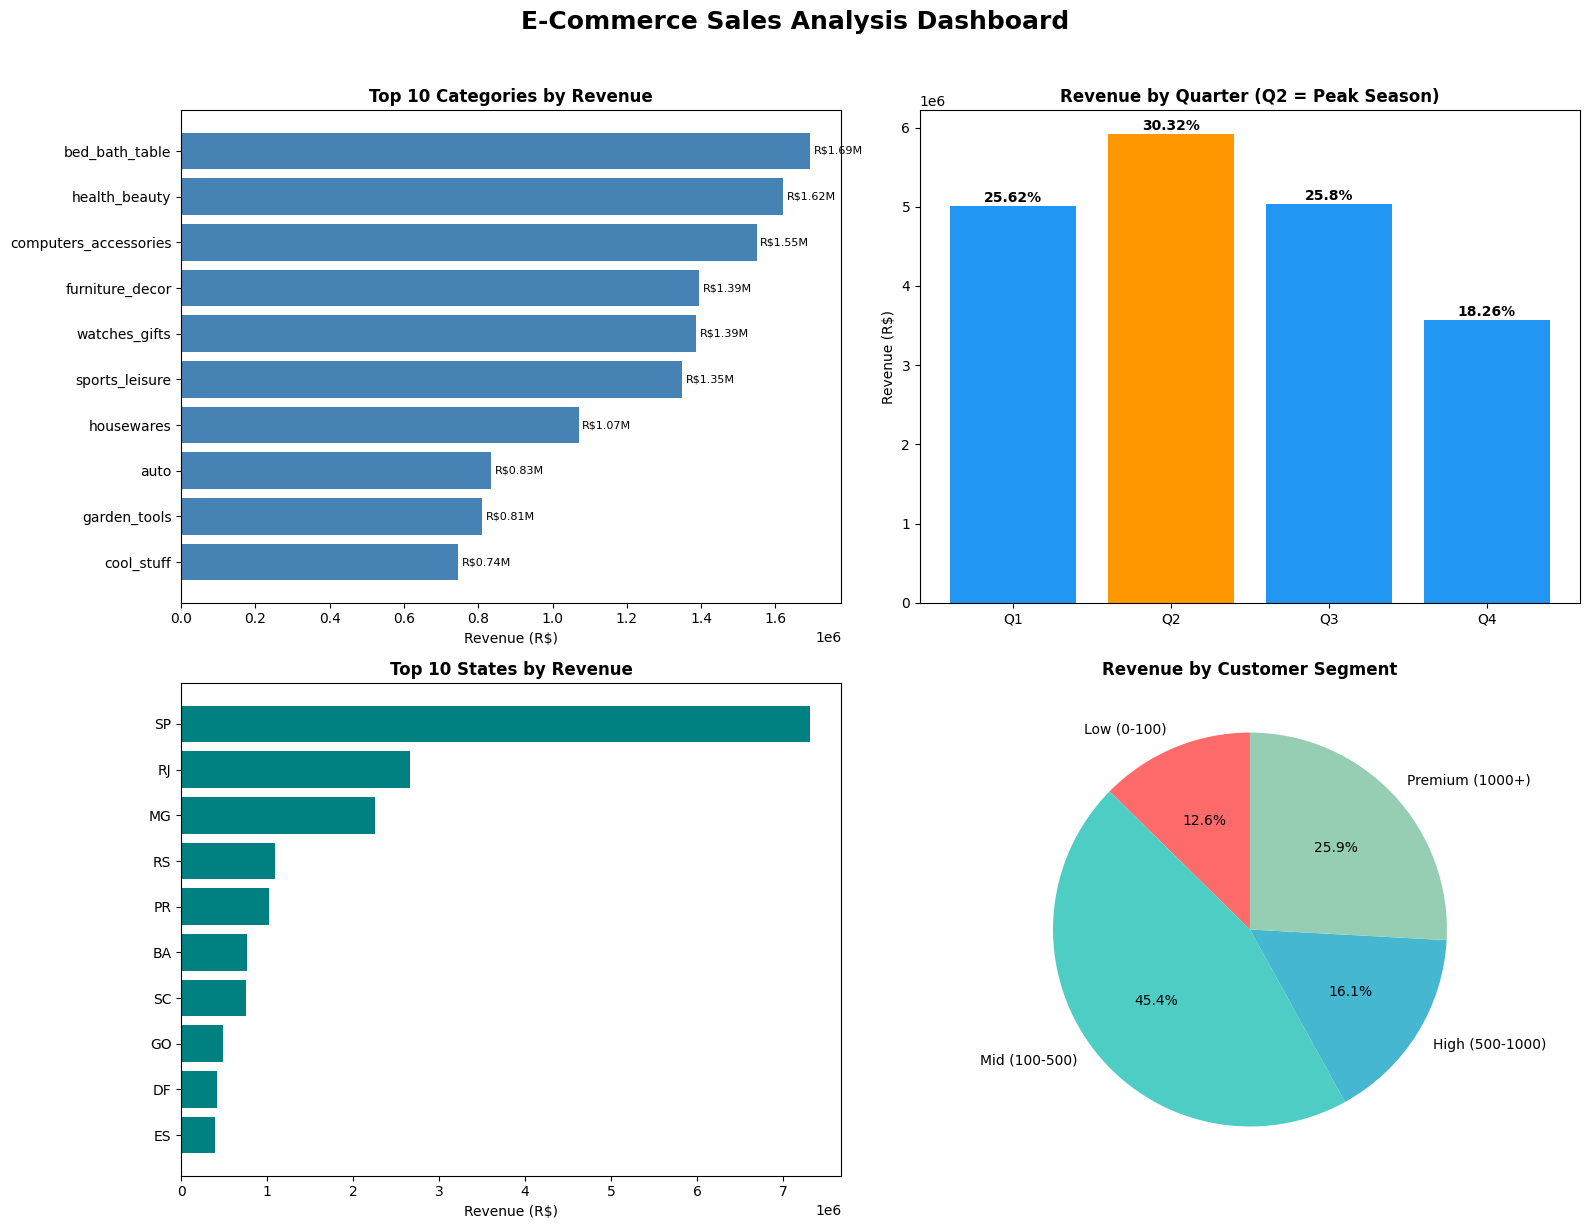

✅ Chart saved in visuals folder!


In [8]:
# ============================================
# VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-Commerce Sales Analysis Dashboard', fontsize=18, fontweight='bold', y=1.02)

# ---- Chart 1: Top 10 Categories by Revenue ----
top_cat = category_revenue.head(10).sort_values()
axes[0,0].barh(top_cat.index, top_cat.values, color='steelblue')
axes[0,0].set_title('Top 10 Categories by Revenue', fontweight='bold')
axes[0,0].set_xlabel('Revenue (R$)')
for i, v in enumerate(top_cat.values):
    axes[0,0].text(v + 10000, i, f'R${v/1e6:.2f}M', va='center', fontsize=8)

# ---- Chart 2: Revenue by Quarter ----
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
q_values = quarterly_revenue.values
colors = ['#2196F3', '#FF9800', '#2196F3', '#2196F3']
bars = axes[0,1].bar(quarters, q_values, color=colors)
axes[0,1].set_title('Revenue by Quarter (Q2 = Peak Season)', fontweight='bold')
axes[0,1].set_ylabel('Revenue (R$)')
for bar, pct in zip(bars, quarterly_pct.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
                   f'{pct}%', ha='center', fontweight='bold')

# ---- Chart 3: Top 10 States by Revenue ----
top_states = state_revenue.head(10).sort_values()
axes[1,0].barh(top_states.index, top_states.values, color='teal')
axes[1,0].set_title('Top 10 States by Revenue', fontweight='bold')
axes[1,0].set_xlabel('Revenue (R$)')

# ---- Chart 4: Customer Segments ----
seg_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
wedges, texts, autotexts = axes[1,1].pie(
    segment_summary['revenue_pct'],
    labels=segment_summary['segment'],
    autopct='%1.1f%%',
    colors=seg_colors,
    startangle=90
)
axes[1,1].set_title('Revenue by Customer Segment', fontweight='bold')

plt.tight_layout()

# Save karo
import os
os.makedirs('/Users/s.faizahmad/Desktop/ecommerce-sales-analysis/visuals', exist_ok=True)
plt.savefig('/Users/s.faizahmad/Desktop/ecommerce-sales-analysis/visuals/dashboard.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved in visuals folder!")

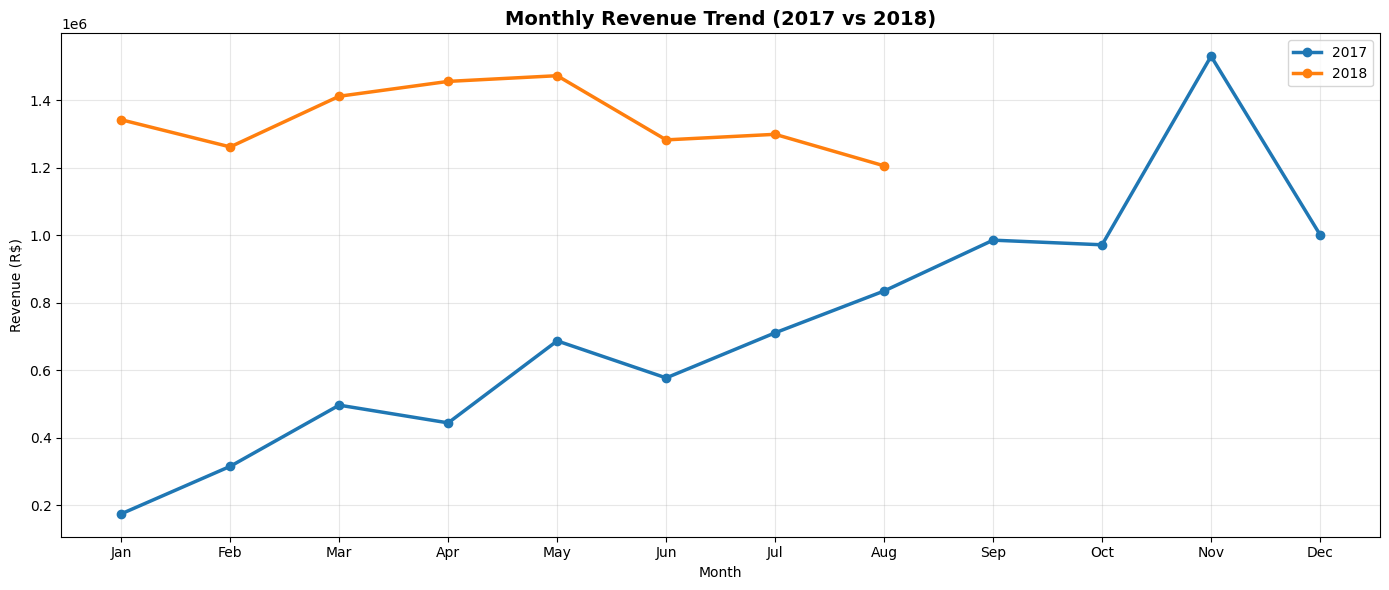

✅ Monthly trend chart saved!


In [9]:
# ============================================
# MONTHLY REVENUE TREND
# ============================================

monthly_revenue = df.groupby(['year', 'month'])['payment_value'].sum().reset_index()
monthly_revenue = monthly_revenue[monthly_revenue['year'].isin([2017, 2018])]
monthly_revenue['date'] = pd.to_datetime(monthly_revenue[['year', 'month']].assign(day=1))
monthly_revenue = monthly_revenue.sort_values('date')

plt.figure(figsize=(14, 6))
for year in [2017, 2018]:
    data = monthly_revenue[monthly_revenue['year'] == year]
    plt.plot(data['month'], data['payment_value'], 
             marker='o', linewidth=2.5, markersize=6, label=str(year))

plt.title('Monthly Revenue Trend (2017 vs 2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('/Users/s.faizahmad/Desktop/ecommerce-sales-analysis/visuals/monthly_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Monthly trend chart saved!")

In [10]:
# ============================================
# SQL ANALYSIS
# ============================================

from sqlalchemy import create_engine

# SQLite database banao
engine = create_engine('sqlite:////Users/s.faizahmad/Desktop/ecommerce-sales-analysis/ecommerce.db')

# Tables load karo database me
orders.to_sql('orders', engine, if_exists='replace', index=False)
order_items.to_sql('order_items', engine, if_exists='replace', index=False)
order_payments.to_sql('order_payments', engine, if_exists='replace', index=False)
customers.to_sql('customers', engine, if_exists='replace', index=False)
products.to_sql('products', engine, if_exists='replace', index=False)
category_translation.to_sql('category_translation', engine, if_exists='replace', index=False)

print("✅ Database created!")

# SQL Query 1 - Top 10 Categories by Revenue
q1 = pd.read_sql("""
    SELECT 
        ct.product_category_name_english AS category,
        ROUND(SUM(op.payment_value), 2) AS total_revenue,
        COUNT(DISTINCT oi.order_id) AS total_orders
    FROM order_items oi
    JOIN order_payments op ON oi.order_id = op.order_id
    JOIN products p ON oi.product_id = p.product_id
    JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 10
""", engine)

print("\n📦 Top 10 Categories (SQL):")
print(q1.to_string(index=False))

# SQL Query 2 - Revenue by State
q2 = pd.read_sql("""
    SELECT 
        c.customer_state AS state,
        ROUND(SUM(op.payment_value), 2) AS total_revenue,
        COUNT(DISTINCT o.order_id) AS total_orders
    FROM orders o
    JOIN order_payments op ON o.order_id = op.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY state
    ORDER BY total_revenue DESC
    LIMIT 10
""", engine)

print("\n🗺️ Top 10 States (SQL):")
print(q2.to_string(index=False))

# SQL Query 3 - Monthly Revenue
q3 = pd.read_sql("""
    SELECT 
        strftime('%Y', o.order_purchase_timestamp) AS year,
        strftime('%m', o.order_purchase_timestamp) AS month,
        ROUND(SUM(op.payment_value), 2) AS monthly_revenue,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(AVG(op.payment_value), 2) AS avg_order_value
    FROM orders o
    JOIN order_payments op ON o.order_id = op.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY year, month
    ORDER BY year, month
""", engine)

print("\n📅 Monthly Revenue (SQL):")
print(q3.to_string(index=False))

✅ Database created!

📦 Top 10 Categories (SQL):
             category  total_revenue  total_orders
       bed_bath_table     1712553.67          9417
        health_beauty     1657373.12          8835
computers_accessories     1585330.45          6689
      furniture_decor     1430176.39          6449
        watches_gifts     1429216.68          5624
       sports_leisure     1392127.56          7720
           housewares     1094758.13          5884
                 auto      852294.33          3897
         garden_tools      838280.75          3518
           cool_stuff      779698.00          3632

🗺️ Top 10 States (SQL):
state  total_revenue  total_orders
   SP     5770266.19         40500
   RJ     2055690.45         12350
   MG     1819277.61         11354
   RS      861802.40          5345
   PR      781919.55          4923
   SC      595208.40          3546
   BA      591270.60          3256
   DF      346146.17          2080
   GO      334294.22          1957
   ES      31768

In [11]:
# ============================================
# SQL QUERIES FILE SAVE KARO
# ============================================

sql_queries = """
-- E-Commerce Sales Analysis SQL Queries
-- Dataset: Olist Brazilian E-Commerce

-- Query 1: Top 10 Categories by Revenue
SELECT 
    ct.product_category_name_english AS category,
    ROUND(SUM(op.payment_value), 2) AS total_revenue,
    COUNT(DISTINCT oi.order_id) AS total_orders
FROM order_items oi
JOIN order_payments op ON oi.order_id = op.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10;

-- Query 2: Revenue by State
SELECT 
    c.customer_state AS state,
    ROUND(SUM(op.payment_value), 2) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN order_payments op ON o.order_id = op.order_id
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY state
ORDER BY total_revenue DESC
LIMIT 10;

-- Query 3: Monthly Revenue Trend
SELECT 
    strftime('%Y', o.order_purchase_timestamp) AS year,
    strftime('%m', o.order_purchase_timestamp) AS month,
    ROUND(SUM(op.payment_value), 2) AS monthly_revenue,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(AVG(op.payment_value), 2) AS avg_order_value
FROM orders o
JOIN order_payments op ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
GROUP BY year, month
ORDER BY year, month;

-- Query 4: Customer Segmentation by Revenue
SELECT 
    CASE 
        WHEN total_revenue <= 100 THEN 'Low (0-100)'
        WHEN total_revenue <= 500 THEN 'Mid (100-500)'
        WHEN total_revenue <= 1000 THEN 'High (500-1000)'
        ELSE 'Premium (1000+)'
    END AS segment,
    COUNT(*) AS customer_count,
    ROUND(SUM(total_revenue), 2) AS segment_revenue
FROM (
    SELECT c.customer_unique_id, 
           SUM(op.payment_value) AS total_revenue
    FROM orders o
    JOIN order_payments op ON o.order_id = op.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
) customer_totals
GROUP BY segment
ORDER BY segment_revenue DESC;
"""

with open('/Users/s.faizahmad/Desktop/ecommerce-sales-analysis/sql/queries.sql', 'w') as f:
    f.write(sql_queries)

print("✅ SQL file saved!")
print("\n🎉 Analysis Complete! Summary:")
print(f"   💰 Total Revenue: R$ 19,528,954")
print(f"   🛒 AOV: R$ 205.30")
print(f"   📦 Top Category: Bed Bath Table (R$ 1.71M)")
print(f"   🗺️ Top State: São Paulo (R$ 5.77M)")
print(f"   👥 Total Customers: 92,078")
print(f"   📅 Peak Month: November 2017 (R$ 1.15M)")
print(f"   💎 Top 18.49% customers = 60% of revenue")

✅ SQL file saved!

🎉 Analysis Complete! Summary:
   💰 Total Revenue: R$ 19,528,954
   🛒 AOV: R$ 205.30
   📦 Top Category: Bed Bath Table (R$ 1.71M)
   🗺️ Top State: São Paulo (R$ 5.77M)
   👥 Total Customers: 92,078
   📅 Peak Month: November 2017 (R$ 1.15M)
   💎 Top 18.49% customers = 60% of revenue
